# Cyber Trend Forecasting - B-MTGNN Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the Bayesian Multivariate Time Graph Neural Network (B-MTGNN). It handles the end-to-end workflow
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Data Preprocessing** Executes the data preparation scripts to construct the Adjacency Matrix and format the time series
2.  **Training:** Executes `Train.py` to train the Bayesian-MTGNN.
3.  **Forecasting:** Runs `forecast_export.py` to predict the next 36 months.
4.  **Visualisation:** Runs `Visualise_Results.py` to display Figure 4 continuous trend plots, highlighting the "Risk Gap" between threats and Pertinent Alleviation Technologies (PATs).

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [1]:
import os
import sys
import contextlib

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Data_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import Colab_Utils
        # This creates a temporary black hole for the print statements
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
            Colab_Utils.setup_environment(PIPELINE_DIR)
        print("Dependencies verified successfully!")
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

--- Detected Environment: LOCAL SERVER (NATO/BBK) ---
SUCCESS: Working Directory set to: /mnt/c/Workspace/Research/Cyber-trend-forecasting/Data_Pipeline
Added Project Root to sys.path: /mnt/c/Workspace/Research/Cyber-trend-forecasting


### Imports

In [2]:
import os
import glob
from IPython.display import display, Image
from pathlib import Path


### Configuration & Experiment Tagging

Set the environment variable below to uniquely tag the outputs of this execution. This tag is dynamically appended to all exported NumPy arrays and intercepted by the downstream visualisation scripts. This ensures legacy results (e.g., Mark 2 baselines) are preserved and not overwritten during subsequent runs.

In [3]:
os.environ['EXPERIMENT_TAG'] = "_Mark3.2_SARIMAX"

### Graph & Data Preprocessing

This step ensures the raw CSV data is properly formatted for the Graph Neural Network. It processes the historical time series and constructs the underlying spatial graph (Adjacency Matrix) linking threats to their respective solutions.

In [4]:
!{sys.executable} -W ignore Prep_Unsmoothed_Data.py

--- Initiating Phase 1: B-MTGNN Data Preparation ---
Loading raw dataset from: Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv
Original dataset shape: (174, 1232) (Months x Columns)
Filtered dataset shape: (174, 123) (Months x Columns)
Applying np.clip to sanitize data (setting minimum bound to 0.0)...
Comparing new data against existing working file...
Exporting legacy B-MTGNN matrix to: Processed_Data/B-MTGNN/sm_data.txt
Exporting VisionTS++ CSV to: Processed_Data/VisionTS/Mark3_Clipped_Data.csv
Archiving B-MTGNN matrix to: Processed_Data/B-MTGNN/Archive/sm_data_Cyber_Trend_Forecasting_All_v2_2_sarimax.txt
Archiving VisionTS++ CSV to: Processed_Data/VisionTS/Archive/clipped_Cyber_Trend_Forecasting_All_v2_2_sarimax.csv

SUCCESS: Phase 1 Data preparation and archiving complete.
Legacy Matrix saved to: /mnt/c/Workspace/Research/Cyber-trend-forecasting/Processed_Data/B-MTGNN/sm_data.txt
VisionTS++ CSV saved to: /mnt/c/Workspace/Research/Cyber-trend-forecasting/Processed_Dat

### Hyperparameter Grid Search
We execute a random grid search to identify the optimal spatial and temporal graph configurations for the new Mark 3 dataset topology.

- Input: The processed `.txt` data and `graph.csv` adjacency mappings.
- Output: `hp.txt` (Saved optimal hyperparameters).

Note: We use `%run` to execute this natively within the notebook, providing live iteration updates.

In [5]:
%%capture
# Hop over to B-MTGNN folder
bmtgnn_dir = os.path.join(PROJECT_ROOT, 'B-MTGNN')
os.chdir(bmtgnn_dir)
print(f"Swapped Working Directory to: {os.getcwd()}")

print("--- Step 1: Grid Search ---")
# Run the Grid Search without printouts
%run train_test.py --data ../Processed_Data/B-MTGNN/sm_data.txt --epochs 50 --batch_size 16 --num_nodes 123

### Train B-MTGNN Model
We now execute the training script.

- Input: The processed `.txt` data and `graph.csv` adjacency mappings.

- Output: `o_model.pt` (Saved model weights).

Note: You can easily adjust the `--epochs`, `--batch_size`, and `--num_nodes` directly in the `%run` command below for demonstration purposes.

We use `%run` to execute the script natively within the notebook namespace,
providing live epoch updates and progress outputs.

In [ ]:
%%capture train_output
print("--- Step 2: Training B-MTGNN Model ---")
%run train.py --data ../Processed_Data/B-MTGNN/sm_data.txt --epochs 50 --batch_size 16 --num_nodes 123

# Render only the final status line from training logs
train_lines = train_output.stdout.splitlines()
summary_lines = [line for line in train_lines if "epoch:" in line or "loss:" in line or "SUCCESS" in line]
print("\n".join(summary_lines[-5:] if summary_lines else train_lines[-5:]))

--- Step 2: Training B-MTGNN Model ---
hp [1, 0.001, 16, 32, 256, 1024, 70, 0.6, 1, 100, 0.4, 1, 1, 50]
Graph loaded with 26 attacks...
123 columns loaded...
Adjacency created...
Namespace(data='../Processed_Data/B-MTGNN/sm_data.txt', log_interval=2000, save='model/Bayesian/o_model.pt', optim='adam', L1Loss=True, normalize=2, device='cuda:1', gcn_true=True, buildA_true=True, gcn_depth=2, num_nodes=123, dropout=0.3, subgraph_size=20, node_dim=40, dilation_exponential=2, conv_channels=16, residual_channels=16, skip_channels=32, end_channels=64, in_dim=1, seq_in_len=10, seq_out_len=36, horizon=1, layers=5, batch_size=16, lr=0.001, weight_decay=1e-05, clip=10, propalpha=0.05, tanhalpha=3, epochs=50, num_split=1, step_size=100)
The recpetive field size is 7
Number of model parameters is 404708
begin training
epoch: 1
iter:  0 | loss: 0.150
iter:  1 | loss: 0.151
epoch: 2
iter:  0 | loss: 0.129
iter:  1 | loss: 0.112
epoch: 3
iter:  0 | loss: 0.103
iter:  1 | loss: 0.096
epoch: 4
iter:  0 | 

### Multi-Horizon Evaluation Extraction

Execution: Loads the trained B-MTGNN model and historical testing dataset to compute standard forecasting error metrics (RSE, RAE, MAE, CORR) across discrete temporal horizons (3, 6, 12, and 24 months).

Outputs: Generates a structured evaluation table and saves it as `graph_evaluation_results.csv` for comparative analysis.

In [4]:
# : Multi-Horizon Evaluation Extraction
# Shift working directory to B-MTGNN so util.py can find its hardcoded data/graph.csv
# if not running grid search or training above - else comment out
bmtgnn_dir = os.path.join(PROJECT_ROOT, 'B-MTGNN')
os.chdir(bmtgnn_dir)

print("--- Step Evaluation: Generating Horizon Evaluation Metrics ---")
# Execute the script located in the Data_Pipeline folder
%run ../Data_Pipeline/Evaluation_Metrics.py

--- Step Evaluation: Generating Horizon Evaluation Metrics ---
Graph loaded with 26 attacks...
123 columns loaded...
Adjacency created...
Evaluation Results:
  Horizon      RSE      RAE       MAE      CORR
 3 Months 1.211220 1.130605 16.027962 -0.104001
 6 Months 1.151469 1.163853 18.587872 -0.123859
12 Months 2.266635 1.648991 17.990545  0.130990
24 Months 1.118744 1.198836 17.185167  0.058280
  Overall 1.265243 1.299966 19.380108 -0.007156

Saved results table to Data_Pipeline/Results/graph_evaluation_results.csv


### Future Forecasting (36-Months)


Execution: Runs the Bayesian estimation over 10 iterations to for the mean prediction and standard deviation.

Outputs: Extracts the forecast matrices and 95% confidence intervals, saving them as `.npy` arrays for visualisation.

In [4]:
# Hop back to Pipeline folder
os.chdir(PIPELINE_DIR)
print(f"Swapped Working Directory to: {os.getcwd()}")

print("--- Step 4: Generating 36-Month Future Forecast ---")
%run forecast_export.py

Swapped Working Directory to: /mnt/c/Workspace/Research/Cyber-trend-forecasting/Data_Pipeline
--- Step 4: Generating 36-Month Future Forecast ---
Injected /mnt/c/Workspace/Research/Cyber-trend-forecasting/B-MTGNN into system path so PyTorch can find 'net.py'
--- Initiating Phase 4: Forecast Extraction ---
Loading data from: Processed_Data/B-MTGNN/sm_data.txt
Data shape loaded: (174, 123) (Months x Nodes)
Loading model weights from: B-MTGNN/model/Bayesian/o_model.pt
Executing 10 Monte Carlo inference passes...
Calculating Bayesian Mean and 95% Confidence Intervals...

--- Saving Arrays for Phase 5 ---
Saved: predictions_Mark3.2_SARIMAX.npy Shape: (1, 36, 123)
Saved: confidence_Mark3.2_SARIMAX.npy Shape: (1, 36, 123)
Saved: history_data_Mark3.2_SARIMAX.npy Shape: (174, 123)
Saved: node_names_Mark3.2_SARIMAX.npy Count: 123
SUCCESS: Phase 4 complete. Data is ready for final visualisation.


### Visualisation & Gap Analysis

Finally, we generate the paper-ready plots (Figure 4).
This script reads the exported arrays, applies Plot-Specific Normalisation to ensure low-volume threats remain readable, and visually shades the "Risk Gap" where threats outpace their Pertinent Alleviation Technologies (PATs).

In [5]:
print("--- Step 5: Generating Figure 4 Visualisations ---")
%run Visualise_Comparison.py

--- Step 5: Generating Figure 4 Visualisations ---
--- Initiating Phase 5: Comparative Visualisation ---
Successfully loaded B-MTGNN arrays (123 Features).

Generating plots for 26 Targets...
Saved: Fig4_Account_Hijacking.png (and archived to archive/)
Saved: Fig4_Adversarial_Attack.png (and archived to archive/)
Saved: Fig4_Apt.png (and archived to archive/)
Saved: Fig4_Backdoor.png (and archived to archive/)
Saved: Fig4_Botnet.png (and archived to archive/)
Saved: Fig4_Brute_Force_Attack.png (and archived to archive/)
Saved: Fig4_Cryptojacking.png (and archived to archive/)
Saved: Fig4_Ddos.png (and archived to archive/)
Saved: Fig4_Data_Poisoning.png (and archived to archive/)
Saved: Fig4_Deepfake.png (and archived to archive/)
Saved: Fig4_Disinformation.png (and archived to archive/)
Saved: Fig4_Dns_Spoofing.png (and archived to archive/)
Saved: Fig4_Dropper.png (and archived to archive/)
Saved: Fig4_Insider_Threat.png (and archived to archive/)
Saved: Fig4_Iot_Device_Attack.png (a


--- Generated 25 B-MTGNN Forecast Plots in /mnt/c/Workspace/Research/Cyber-trend-forecasting/Processed_Data/Comparison_Plots/BMTGNN_Outlook ---
Rendering 3 representative target previews inline:


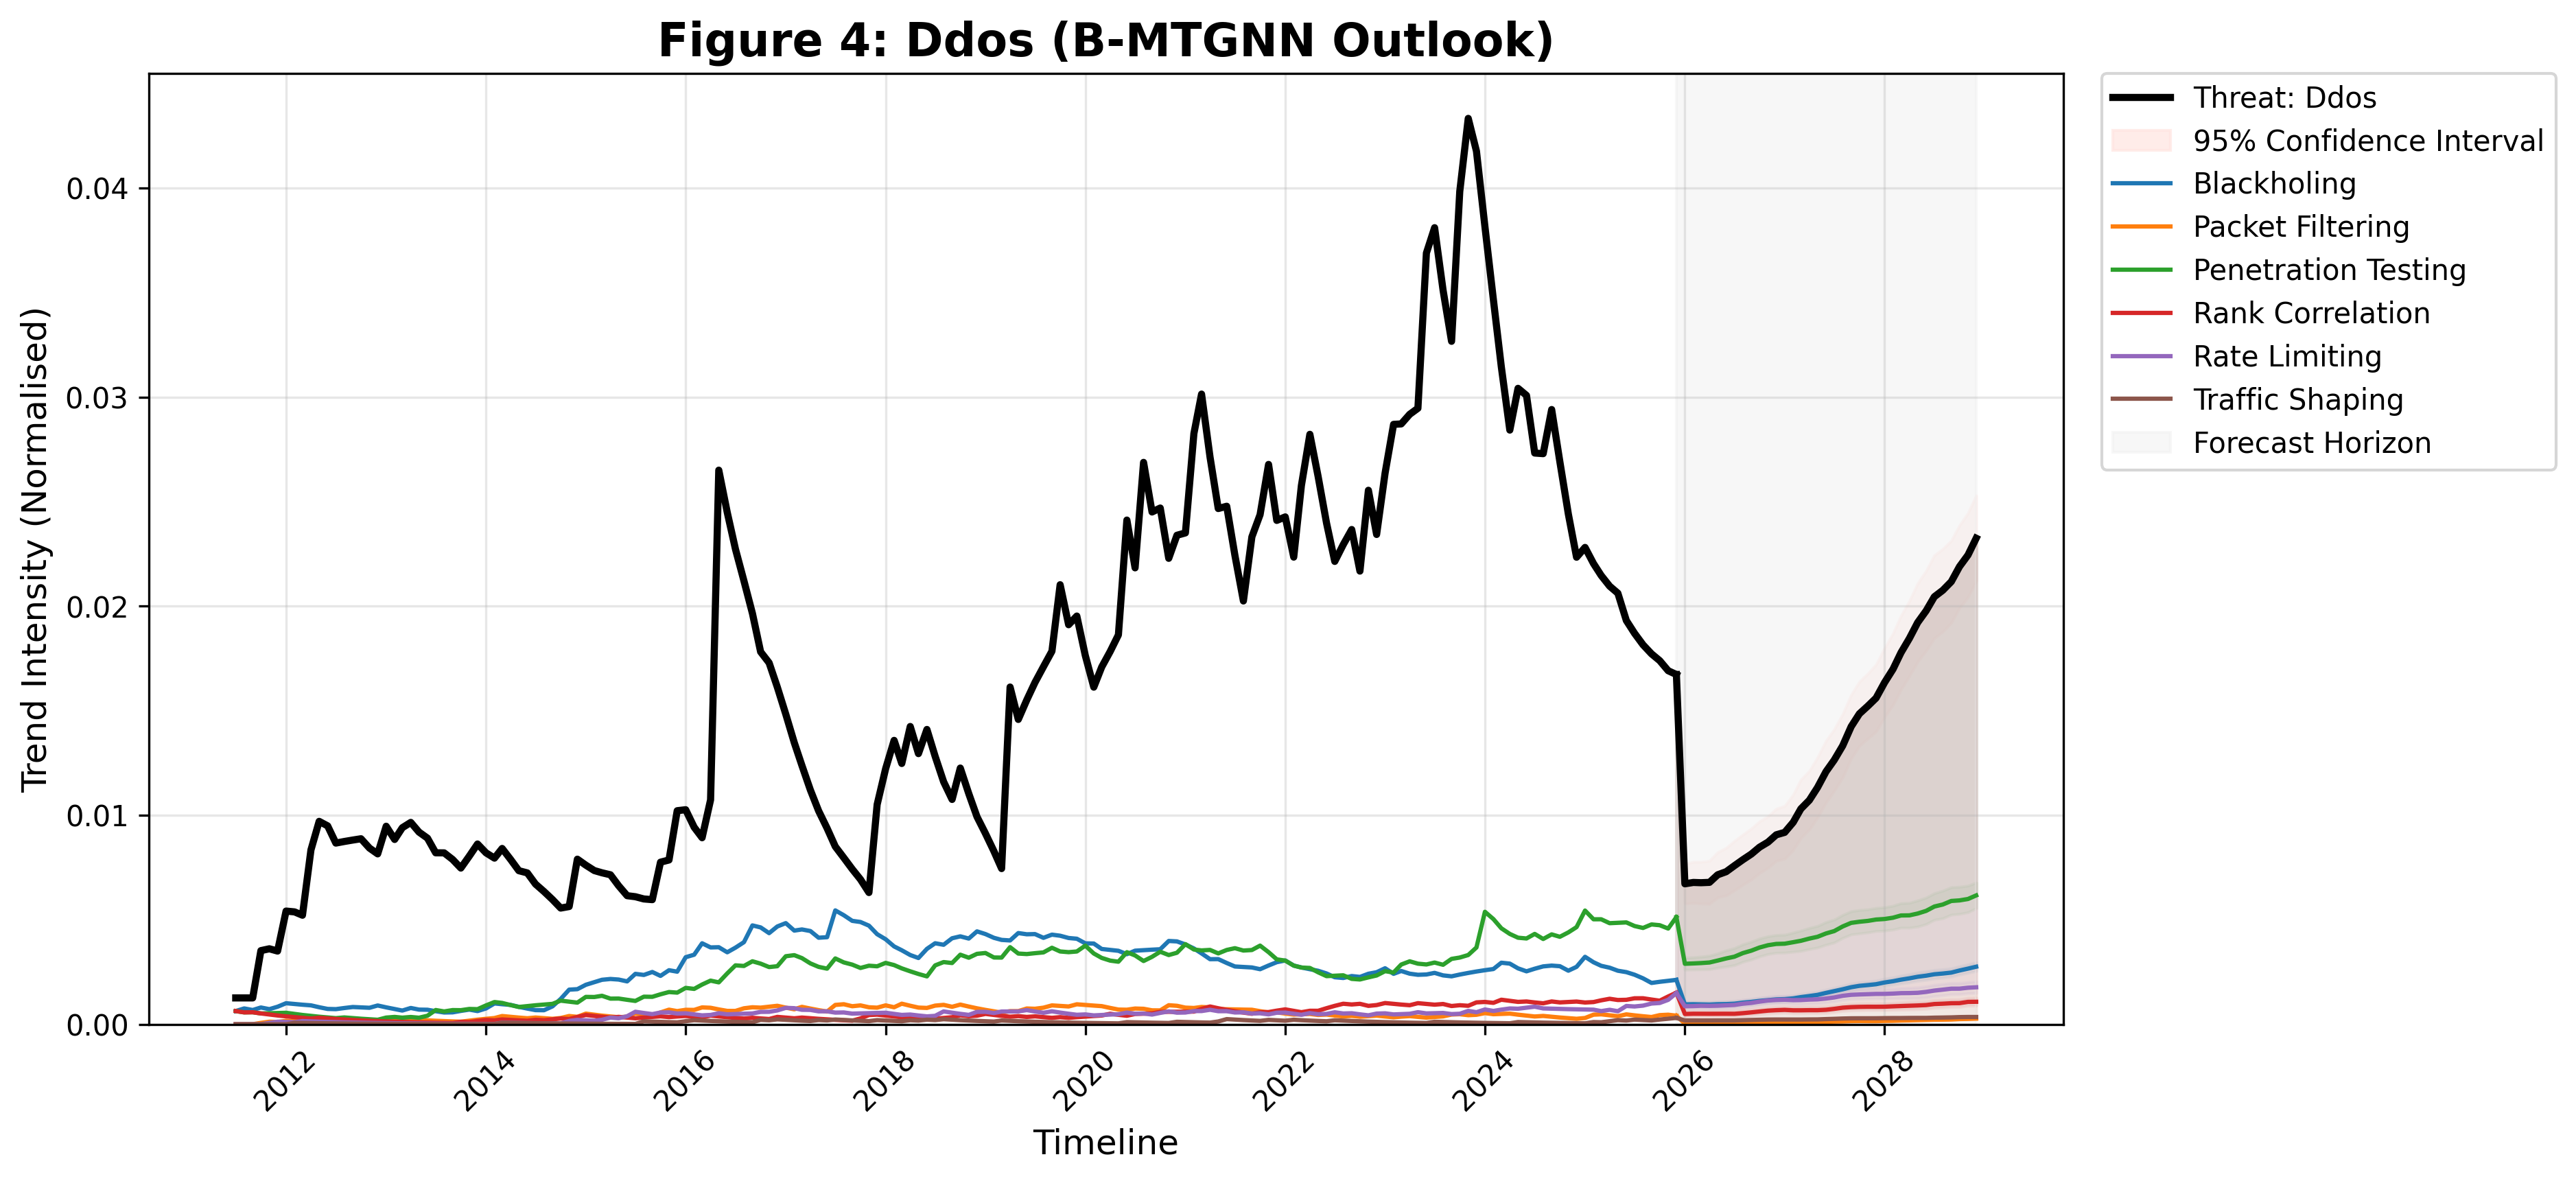

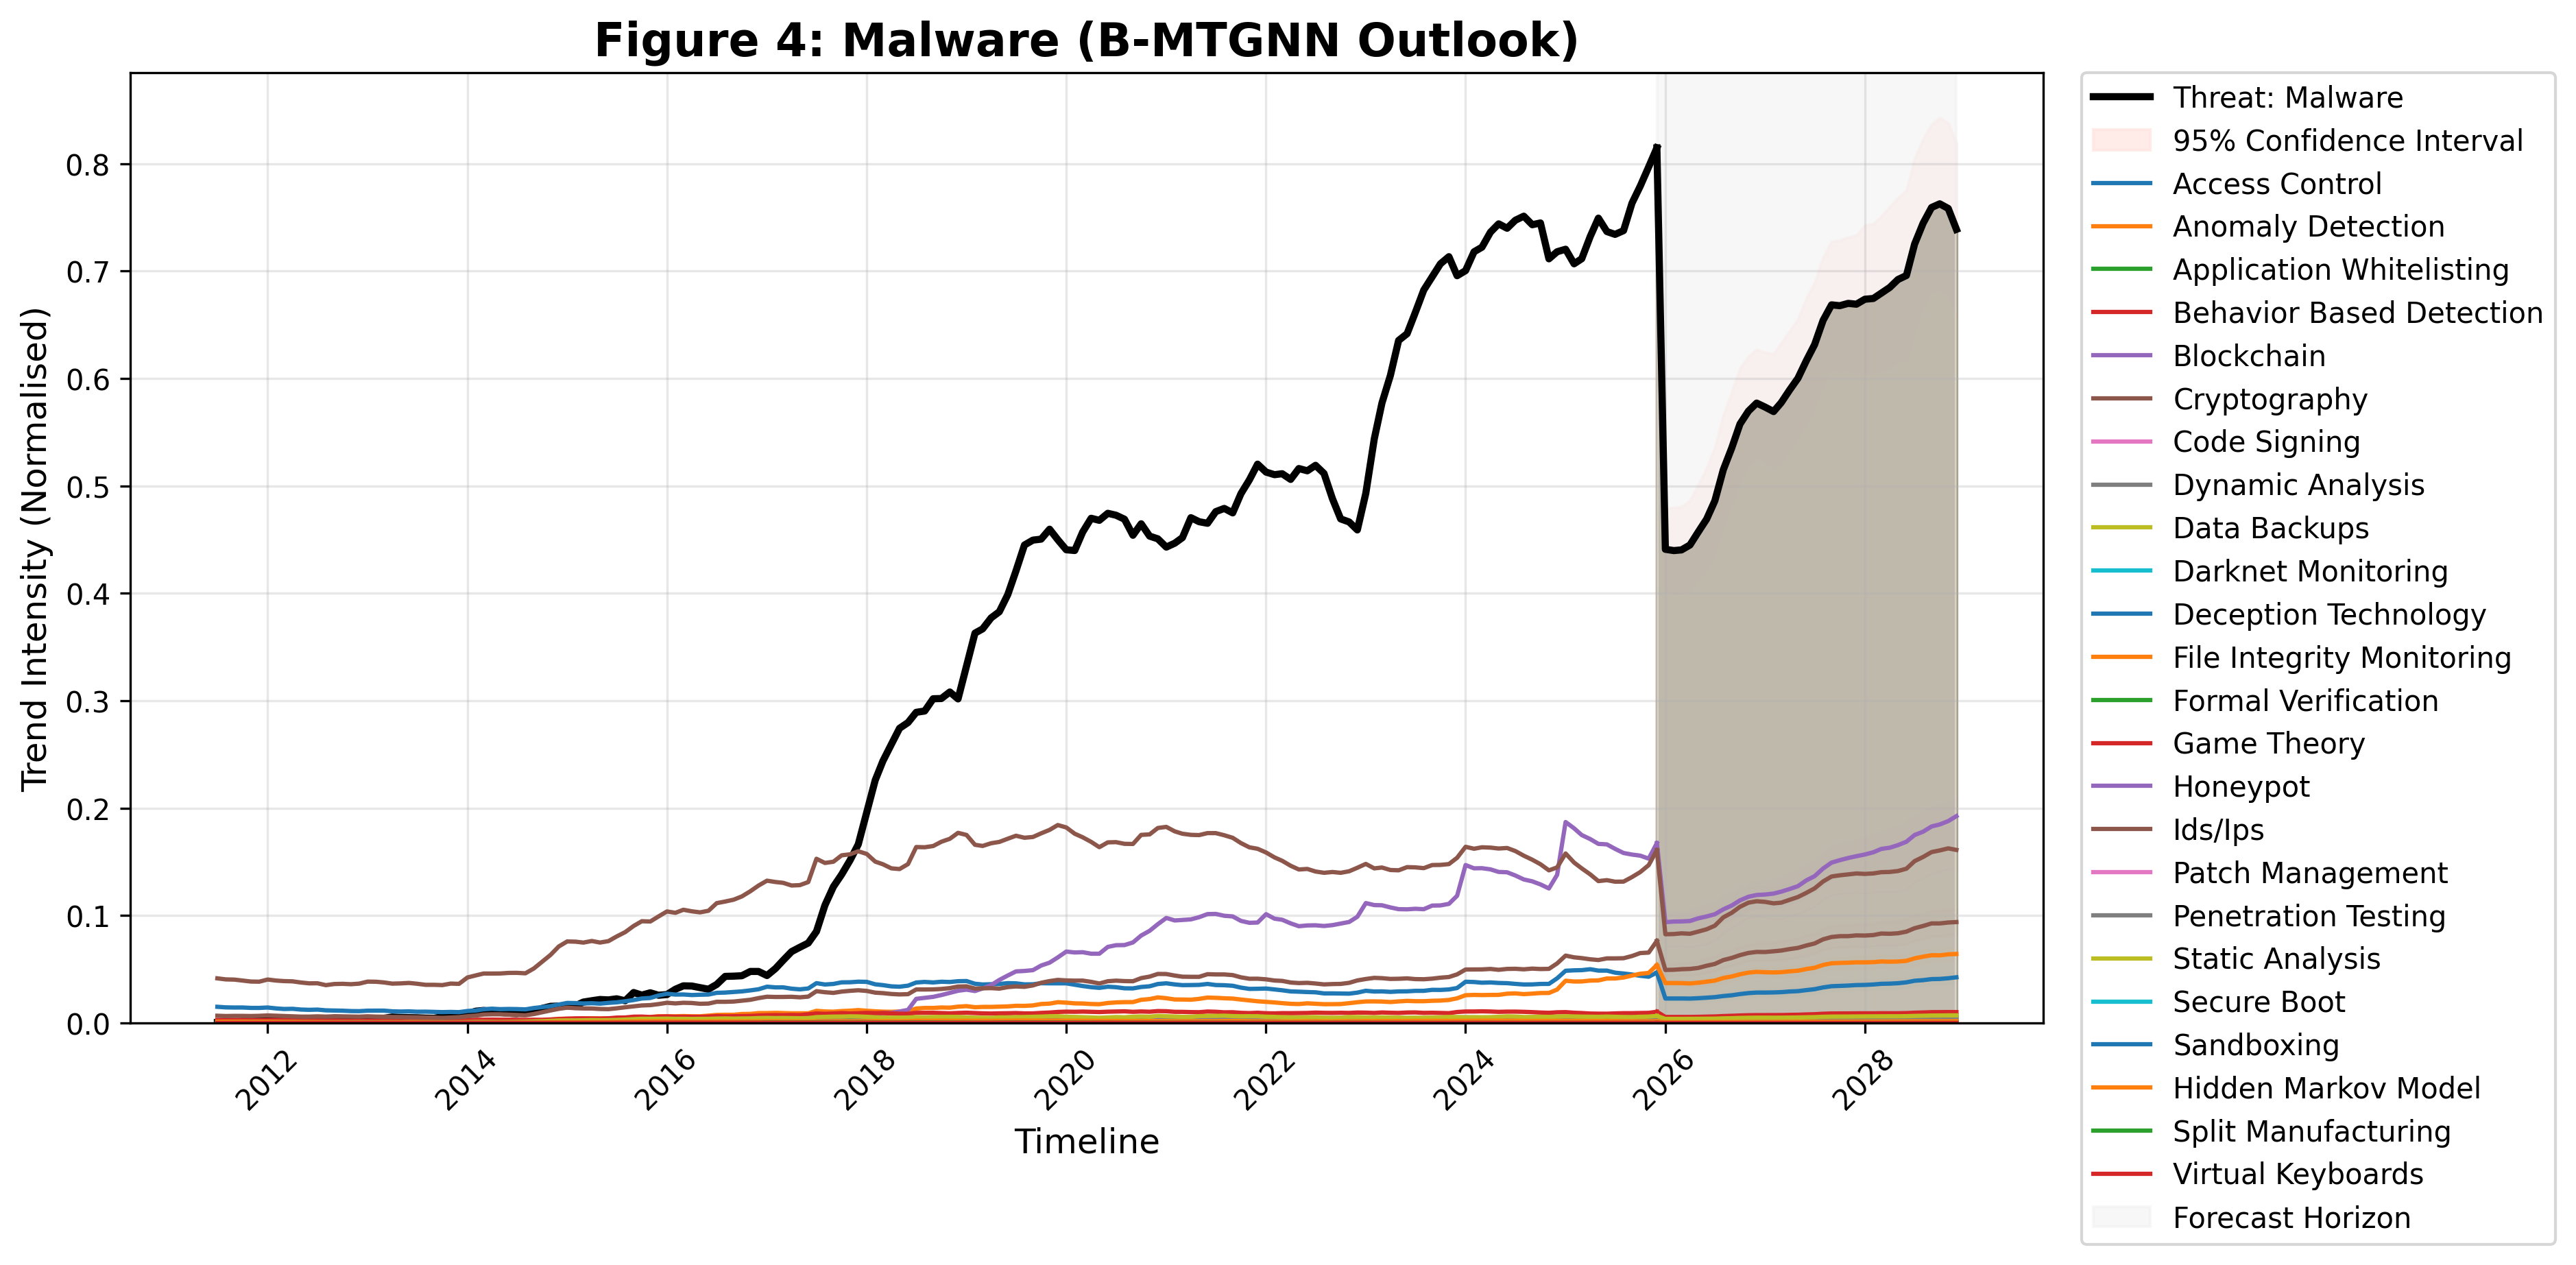

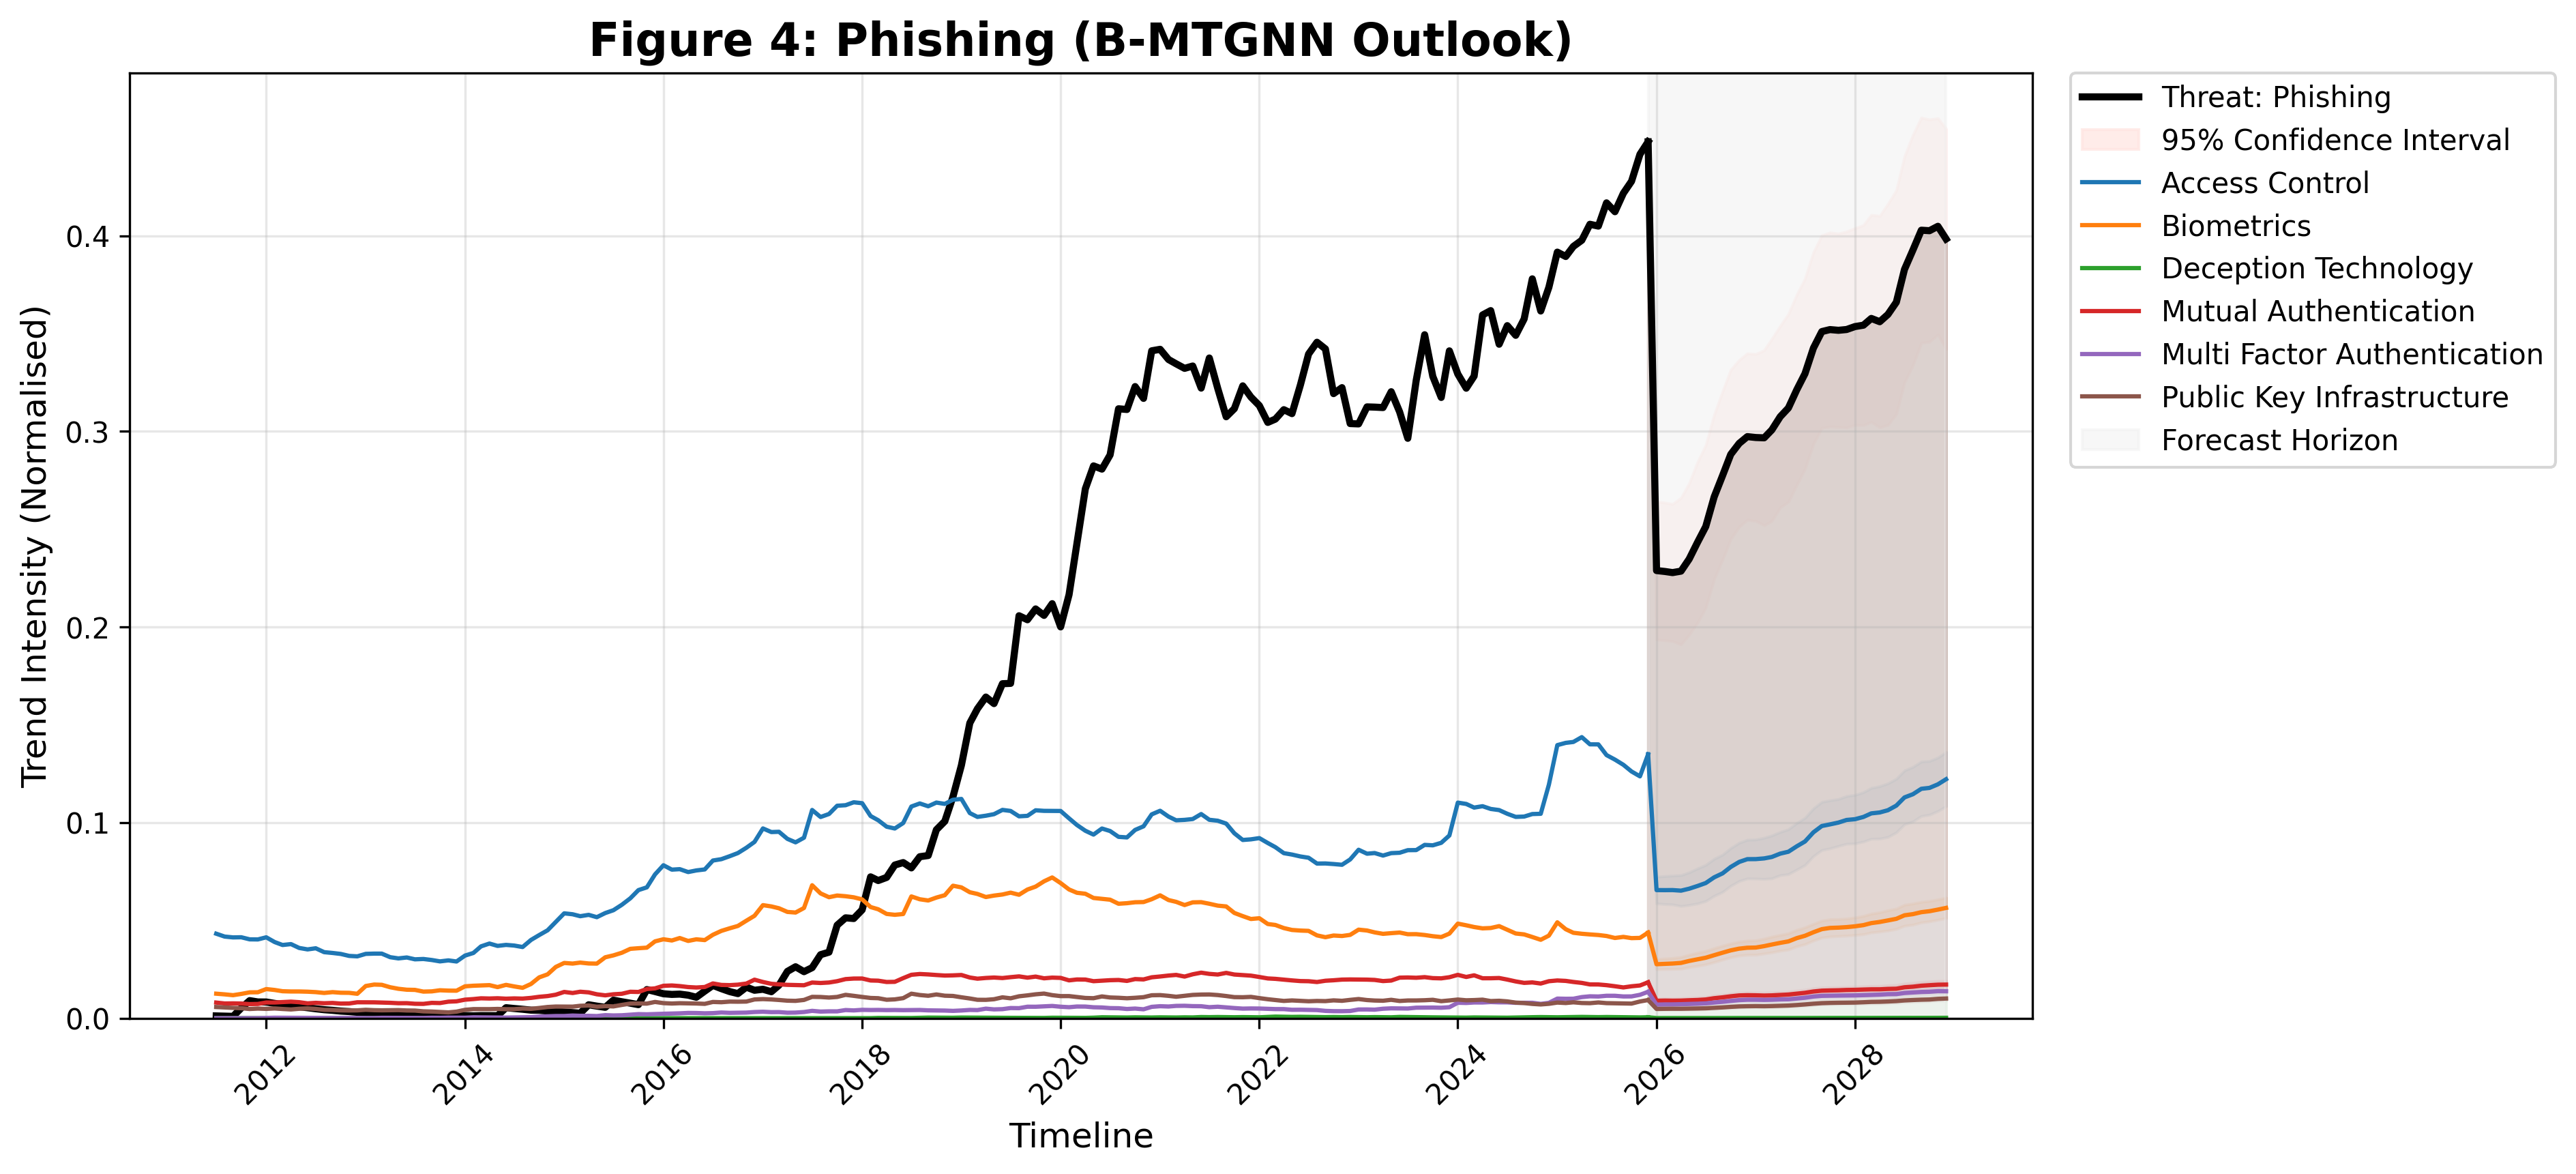

In [6]:
plot_dir = os.path.join(PROJECT_ROOT, 'Processed_Data', 'Comparison_Plots', 'BMTGNN_Outlook')
plot_files = sorted(glob.glob(os.path.join(plot_dir, '*.png')))
print(f"\n--- Generated {len(plot_files)} B-MTGNN Forecast Plots in {plot_dir} ---")

# Display a preview of key targets to prevent notebook lag
preview_targets = ["DDoS", "Malware", "Phishing"]
preview_files = [f for f in plot_files if any(target.lower() in os.path.basename(f).lower() for target in preview_targets)]

print(f"Rendering {len(preview_files)} representative target previews inline:")
for plot_path in preview_files:
    display(Image(filename=plot_path))